# Dummy Variable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy as sp
import scipy.stats as stats

import pyreadr 
import matplotlib.font_manager as fm
from matplotlib import ticker



In [2]:
plt.rcParams["font.family"] = "Arial"

### Figure 6.2

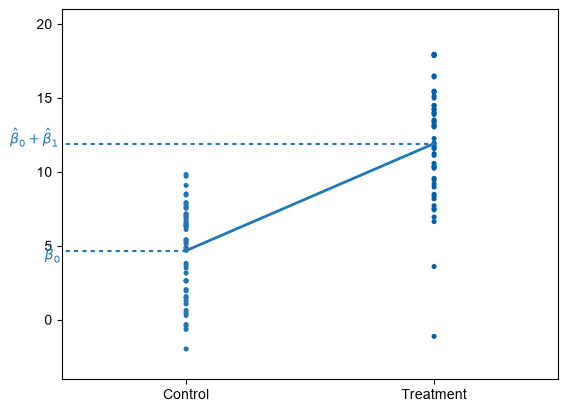

In [4]:
example= pd.DataFrame({"X": np.concatenate([np.zeros(50),np.ones(50)]),
                       "Y": np.concatenate([np.random.normal(loc=4, scale=3, size=50), np.random.normal(loc=12, scale=3.5, size=50)])})
np.random.seed(23)

fig, ax= plt.subplots()

# Because both the groups are colored a bit differently 
colors = np.where(example["X"] == 1, "#0060ac", "C0")
#For 1 keep it #0060ac and for anything other than 1 set C0


ax.scatter(example["X"], example["Y"], color=colors, s=7)


# Changing ticks and fixing the distance between ticks
ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.xaxis.set_major_formatter(ticker.FixedFormatter(["Control","Treatment"]))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

ax.set_ylim(-4,21)
ax.set_xlim(xmin=-0.5, xmax=1.5)


# To draw the line between the averages

mean0 = example.loc[example["X"] == 0, "Y"].mean()
mean1 = example.loc[example["X"] == 1, "Y"].mean()

# Connect the means
ax.plot([0, 1], [mean0, mean1], color="C0", linewidth=2)

#Labels
ax.hlines(mean1, -4, 1, linestyles=(0,(2,2)), color="C0")
ax.hlines(mean0, -4, 0, linestyles=(0,(2,2)), color="C0")

ax.text(-0.71, mean1, r"$\hat{\beta}_0 + \hat{\beta}_1$", color="C0")
ax.text(-0.57, mean0-0.6, r"$\hat{\beta}_0$", color="C0")
plt.show()


### Figure 6.3

This figure uses jitter, so while otherwise all of this would have been in a straight line, now we have a cloud of points, this prevents overlaps and allows one to visually decern the quantity of observations.

Now seaborn library does have an automatic jitter function, we will first to make this graph using that, and then go back to matplotlib to add a jitter on our own

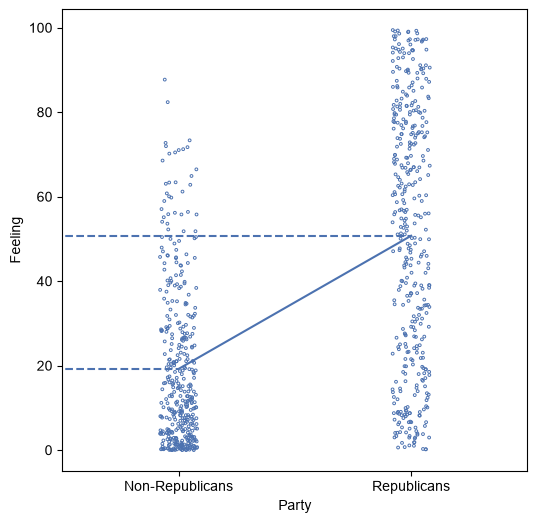

In [146]:
np.random.seed(23)

example = pd.DataFrame({
    "Party": np.concatenate([np.zeros(400), np.ones(400)]),
    "Feeling": np.concatenate([
        np.random.beta(0.7, 3, 400) * 100,
        np.random.uniform(0, 100, 400)
    ])
})

fig, ax = plt.subplots(figsize=(6,6))

sns.stripplot(
    data=example,
    x="Party",
    y="Feeling",
    jitter=0.08,                #Adding jitter of 0.08
    size=2,
    facecolor="none",           
    edgecolor="#4C72B0",    
    linewidth=0.7,
    ax=ax                       # When using other libraries with matplotlib we have to tell the libraries which axis to draw on, here we only have 1 axis so, ax=ax but for more we would do ax=axes[0] etc.
)

ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.set_xlim(-0.5,1.5)
ax.set_xticklabels(["Non-Republicans", "Republicans"])

mean0 = example.loc[example["Party"]==0, "Feeling"].mean()
mean1 = example.loc[example["Party"]==1, "Feeling"].mean()

ax.plot([0,1],[mean0,mean1], color="#4C72B0")
ax.hlines(mean0, -1, 0, linestyle="--", color="#4C72B0")
ax.hlines(mean1, -1, 1, linestyle="--", color="#4C72B0")


plt.show()

To do the same on matplotlib we simply use numpy to add random value to our values

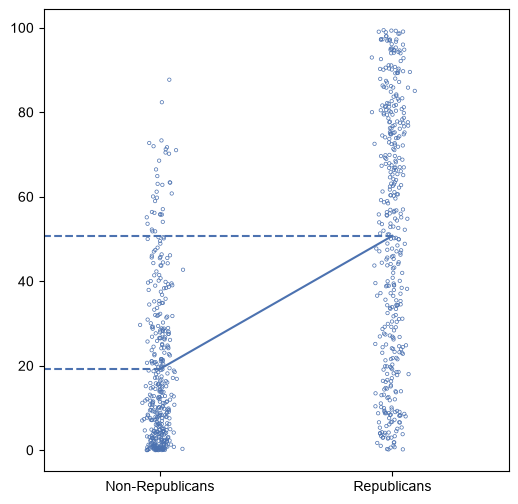

In [147]:
fig, ax = plt.subplots(figsize=(6,6))

#x is all values of "party" plus some random number
x = example["Party"] + np.random.normal(0, 0.03, len(example)) 

ax.scatter(
    x,
    example["Feeling"],
    s=6,
    facecolors="none",
    edgecolors="#4C72B0",
    linewidth=0.5
)

ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.set_xlim(-0.5,1.5)
ax.set_xticklabels(["Non-Republicans", "Republicans"])

mean0 = example.loc[example["Party"]==0, "Feeling"].mean()
mean1 = example.loc[example["Party"]==1, "Feeling"].mean()

ax.plot([0,1],[mean0,mean1], color="#4C72B0")
ax.hlines(mean0, -1, 0, linestyle="--", color="#4C72B0")
ax.hlines(mean1, -1, 1, linestyle="--", color="#4C72B0")


plt.show()

We can also use swarmplot on seaborn, if we want no points to overlap

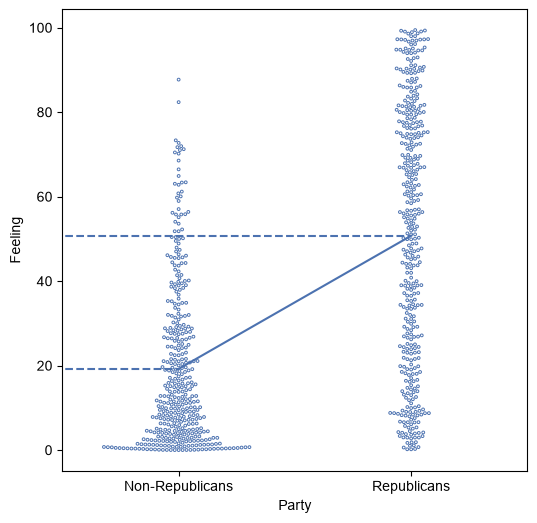

In [ ]:
np.random.seed(23)

example = pd.DataFrame({
    "Party": np.concatenate([np.zeros(400), np.ones(400)]),
    "Feeling": np.concatenate([
        np.random.beta(0.7, 3, 400) * 100,
        np.random.uniform(0, 100, 400)
    ])
})

fig, ax = plt.subplots(figsize=(6,6))

sns.swarmplot(                  #Swarm plot 
    data=example,
    x="Party",
    y="Feeling",               
    size=2,
    facecolor="none",           
    edgecolor="#4C72B0",    
    linewidth=0.7,
    ax=ax                       # When using other libraries with matplotlib we have to tell the libraries which axis to draw on, here we only have 1 axis so, ax=ax but for more we would do ax=axes[0] etc.
)

ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.set_xlim(-0.5,1.5)
ax.set_xticklabels(["Non-Republicans", "Republicans"])

mean0 = example.loc[example["Party"]==0, "Feeling"].mean()
mean1 = example.loc[example["Party"]==1, "Feeling"].mean()

ax.plot([0,1],[mean0,mean1], color="#4C72B0")
ax.hlines(mean0, -1, 0, linestyle="--", color="#4C72B0")
ax.hlines(mean1, -1, 1, linestyle="--", color="#4C72B0")


plt.show()

# Computing Corner

**1.**

Difference of mean test is simply OLS with Y and a dummy\
(Dum is a column of 0 and 1)

`model = smf.ols("Y ~ Dum", data=df).fit()`\
`print(model.summary())`

This OLS is the same as a equal variance two-sample t-test, and will give the same coefficient, SE, t-statistic, and p-value. That test can be done using scipy.stats

In [ ]:
stats.ttest_ind(
    example.loc[example["X"] == 1, "Y"],
    example.loc[example["X"] == 0, "Y"],
    equal_var=True
)

# changing equal_var=False will be Welch t-test or unequal variance t-test

Doing the unequal variance t-test using OLS involves using heteroskedasticity robust standard errors which can be done by adding HC1 argument into our fit function. 

In [ ]:
model = smf.ols("Y ~ Dum", data=df).fit(cov_type="HC1")

Or we can evaluate an OLS just as we have been doing and then ask for our robust results later

In [ ]:
model = smf.ols("Y ~ Dum", data=df).fit()
robust = model.get_robustcov_results(cov_type="HC1")
print(robust.summary())

**2.**

To create an interaction dummy we can simply create an interaction column in our data frame and then us that in our OLS formula

In [ ]:
df["DumInteract"] = df["Dum"] * df["X"]

Alternatively we can ask statsmodel to do the same thing under the hood by using `Dum:X` in the formula 

In [ ]:
model = smf.ols("Y ~ Dum + X + Dum:X", data=df).fit()

In [ ]:
# BUT we can also do 

smf.ols("Y ~ Dum * X", data=df).fit()

This can be a little confusing so here is code and the model side by side

`smf.ols("Y ~ Dum + X", data=df).fit()`
$$
Y= \beta_0 + \beta_1Dum + \beta_2X + u
$$
`model = smf.ols("Y ~ Dum + X + Dum:X", data=df).fit()`
$$
Y= \beta_0 + \beta_1Dum + \beta_2X + \beta_3(Dum \times X) + u
$$
`smf.ols("Y ~ Dum * X", data=df).fit()`
$$
Y= \beta_0 + \beta_1Dum + \beta_2X + \beta_3(Dum \times X) + u
$$


The last code, is similar to R, and it might seem weird why multiplication is acting the same as adding and using `:`. 

`Dum:X` in the `formula=` means that you are asking statsmodel to under the hood multiply `df["Dum"]` and `df["X"]` (row wise) and the resulting column will act as the interaction column exactly as we did earlier at the start of **2.**. 

But importantly, in the `formula=` string `*` is not for multiplication, it actually expands to `Dum + X + Dum:X`

So in statsmodel, `Dum:X` stands for multiplication while `a*b` stands for add a and b and then their multiplication

**3.**

When we talk about a model as follows
$$
Y= \beta_0 + \beta_1X + \beta_2D + \beta_3(D \times X) + u
$$

For $(D=0)$\
The model becomes 
$$
Y= \beta_0 + \beta_1X
$$
and the estimate of effect is simply $\hat{\beta_1}$

But for $(D=1)$\
The model becomes
$$
Y= \beta_0 + \beta_2 + (\beta_1 + \beta_3)X
$$
and the estimate of effect becomes $\hat{\beta_1}+\hat{\beta_3}$

Now for t-test we need standard error or $\sqrt{Var(\hat{\beta_1}+\hat{\beta_3})}$, and we can't simply add the effects and then find the variance when we want to find the $Var(\hat{\beta_1}+\hat{\beta_3})$ 

Why? because,
$$
Var(A+B)= Var(A)+Var(B)+2Cov(A+B)
$$

so, we need covariance between $\hat{\beta_1}$ and $\hat{\beta_3}$

Whenever we run an OLS we internally get a Variance-Covariance matrix which is stored in\
`model.cov_param()`
So we can access them from here and calculate manually the sum but there is also an automatic way.

`model.t_test("X + X:D = 0")`

Will do the t test for us for X when D=1

What this piece of code does is that it is running a t-test on sum of β coefficients of X and X:D i.e.
$$
H_0=\beta_1+\beta_3 = 0\\
or\\
H_0=\beta_X+\beta_{interaction} = 0
$$
So, we don't have to manually find variance and then do the t-test on our own, we can just ask statsmodel to do it for us.
 

In [ ]:
# Just for reference, to do this manually we can find variance by doing

var = (
    cov.loc["X", "X"]
    + cov.loc["X:D", "X:D"]
    + 2 * cov.loc["X", "X:D"]
)

**4.**

To let python know that a variable is a categorical variable we can enclose it in C()

In [ ]:
model = smf.ols("Y ~ C(X1)", data=df).fit()

So if we have say X1 as region where we have North South East and West this C() will make 3 categories and automatically omit one as reference 

Intercept\
Region[T.North]\
Region[T.South]\
Region[T.West]
(T is for treatment and this is how statsmodel and even R stores it's category variables, while accessing the information stored in these categories as well we need to use T, for help with name one can always do `print(model.params.index)` or `model.model.exog_names` (first model is the object in which OLS data is saved the next model is syntax))


The reference is usually the first category alphabetically unless we specify which category should be reference.

To manually select a category to become reference we do:

In [ ]:
model = smf.ols(
    "Y ~ C(X1, Treatment(reference='South'))",
    data=df
).fit()

#Now every coefficient is interpreted relative to South